# Credit Card Customer Churn & Risk Segmentation Dashboard

### Question: Which credit card customer segments are most likely to churn, and what account and usage patterns can predict that risk?

### Stakeholder Framing: A bank's customer retention team requires a queryable tool that ranks currently active customers by churn risk so that retention offers can be targeted at the right customers before they leave.

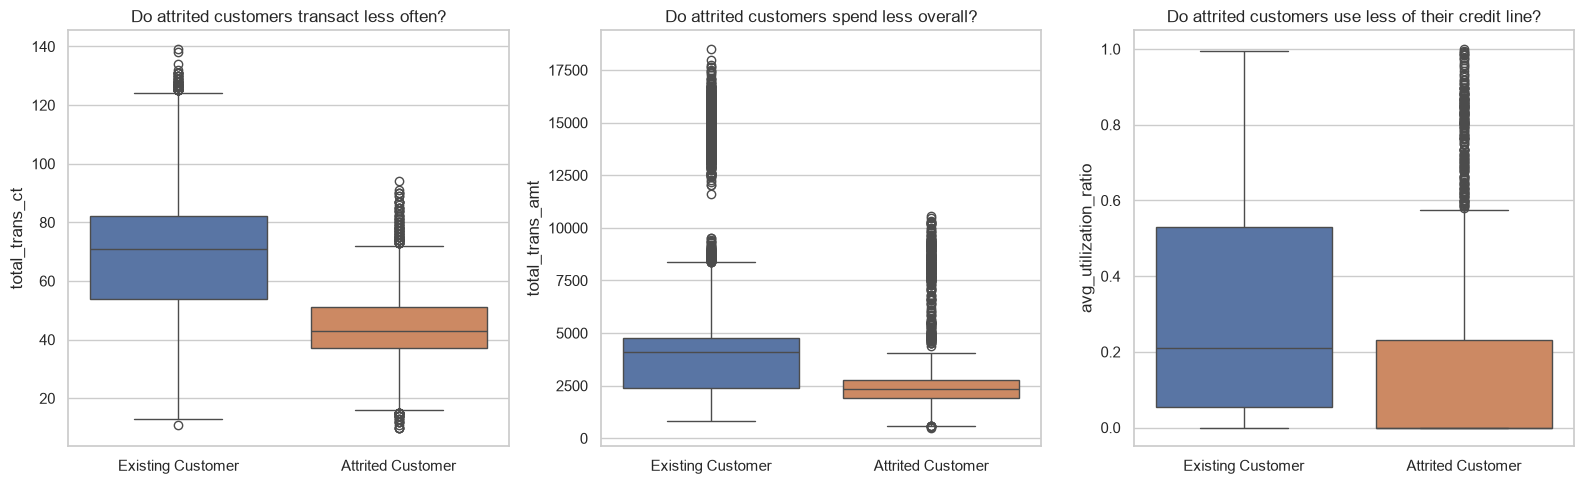

In [11]:
# Churn Risk Analysis
# Comparing attrited vs existing customers

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=features, x="attrition_flag", y="total_trans_ct", ax=axes[0], hue="attrition_flag", legend=False)
axes[0].set_title("Do attrited customers transact less often?")
axes[0].set_xlabel("")

sns.boxplot(data=features, x="attrition_flag", y="total_trans_amt", ax=axes[1], hue="attrition_flag", legend=False)
axes[1].set_title("Do attrited customers spend less overall?")
axes[1].set_xlabel("")

sns.boxplot(data=features, x="attrition_flag", y="avg_utilization_ratio", ax=axes[2], hue="attrition_flag", legend=False)
axes[2].set_title("Do attrited customers use less of their credit line?")
axes[2].set_xlabel("")

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "analysis_eda_comparison.png", dpi=150)
plt.show()

### Analysis Note: Attrited customers have visibly lower transaction counts, spend less overall and use less of their credit line.

In [23]:
# Build risk score

features["trans_ct_percentile"] = features["total_trans_ct"].rank(pct=True)
features["utilization_percentile"] = features["avg_utilization_ratio"].rank(pct=True)

W_TRANS_CT = 0.4
W_UTILIZATION = 0.6

features["churn_risk_score"] = (
    (1 - features["trans_ct_percentile"]) * W_TRANS_CT +
    (1 - features["utilization_percentile"]) * W_UTILIZATION
)

features[["client_num", "attrition_flag", "total_trans_ct", "avg_utilization_ratio", "churn_risk_score"]].head()

,client_num,attrition_flag,total_trans_ct,avg_utilization_ratio,churn_risk_score
0,768805383,Existing Customer,42,0.061,0.721339
1,818770008,Existing Customer,33,0.105,0.717281
2,713982108,Existing Customer,20,0.000,0.922455
3,769911858,Existing Customer,20,0.760,0.436566
4,709106358,Existing Customer,28,0.000,0.906932


Average churn_risk_score by actual outcome:
attrition_flag
Attrited Customer    0.694
Existing Customer    0.463
Name: churn_risk_score, dtype: float64


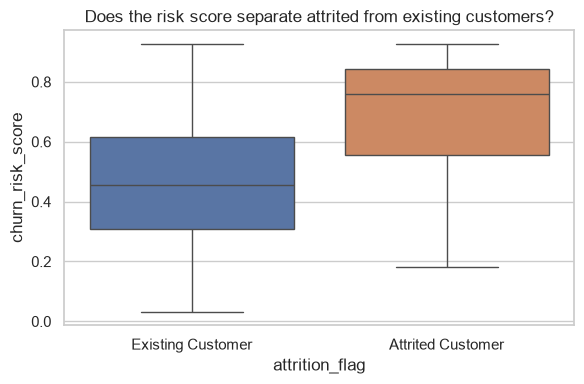

In [24]:
# Validation of risk score

validation = features.groupby("attrition_flag")["churn_risk_score"].mean().round(3)
print("Average churn_risk_score by actual outcome:")
print(validation)

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=features, x="attrition_flag", y="churn_risk_score", hue="attrition_flag", legend=False, ax=ax)
ax.set_title("Does the risk score separate attrited from existing customers?")
plt.tight_layout()
plt.show()

In [25]:
# Risk score table to SQL

features.to_sql("customer_scores", engine, if_exists="replace", index=False)
print("Saved customer_scores table.")

Saved customer_scores table.


In [26]:
summary = features.groupby("attrition_flag")[["total_trans_ct", "avg_utilization_ratio"]].mean()
print(summary)

pct_diff_trans_ct = (
    (summary.loc["Existing Customer", "total_trans_ct"] - summary.loc["Attrited Customer", "total_trans_ct"])
    / summary.loc["Existing Customer", "total_trans_ct"] * 100
)
pct_diff_utilization = (
    (summary.loc["Existing Customer", "avg_utilization_ratio"] - summary.loc["Attrited Customer", "avg_utilization_ratio"])
    / summary.loc["Existing Customer", "avg_utilization_ratio"] * 100
)

print(f"Transaction count: {pct_diff_trans_ct:.1f}% lower for attrited customers")
print(f"Utilization ratio: {pct_diff_utilization:.1f}% lower for attrited customers")

                   total_trans_ct  avg_utilization_ratio
attrition_flag                                          
Attrited Customer       44.933620               0.162475
Existing Customer       68.672588               0.296412
Transaction count: 34.6% lower for attrited customers
Utilization ratio: 45.2% lower for attrited customers


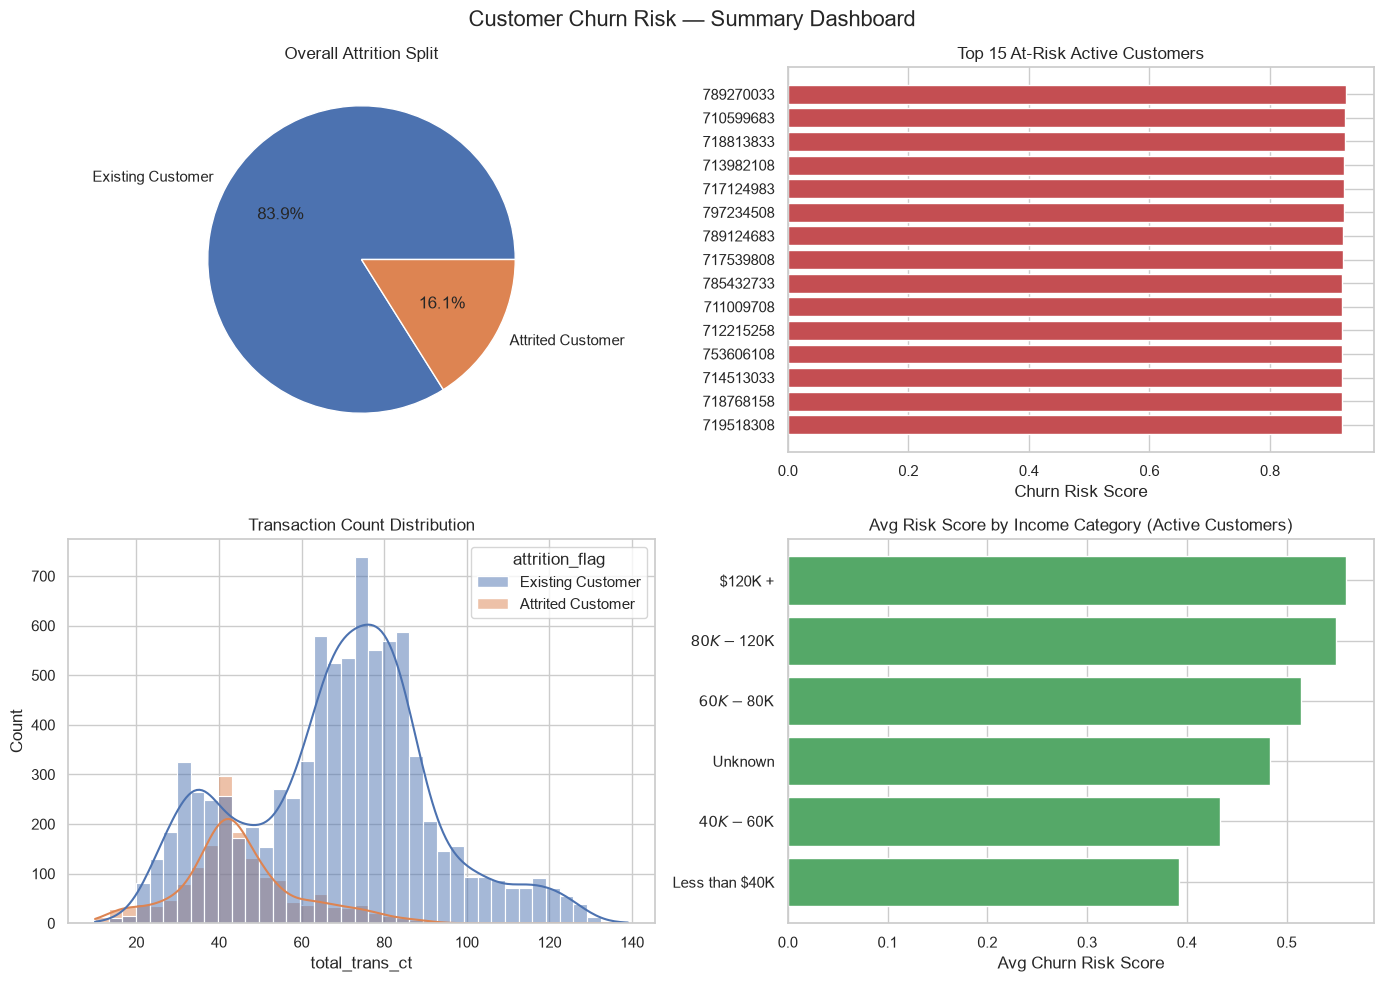

In [27]:
# Summary dashboard

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Customer Churn Risk — Summary Dashboard", fontsize=16)

# Top-left: attrition rate overall
attrition_counts = features["attrition_flag"].value_counts()
axes[0, 0].pie(attrition_counts, labels=attrition_counts.index, autopct="%1.1f%%",
               colors=["#4C72B0", "#DD8452"])
axes[0, 0].set_title("Overall Attrition Split")

# Top-right: top 15 highest-risk ACTIVE customers
active_customers = features[features["attrition_flag"] == "Existing Customer"]
top15 = active_customers.nlargest(15, "churn_risk_score")
axes[0, 1].barh(top15["client_num"].astype(str), top15["churn_risk_score"], color="#C44E52")
axes[0, 1].invert_yaxis()
axes[0, 1].set_title("Top 15 At-Risk Active Customers")
axes[0, 1].set_xlabel("Churn Risk Score")

# Bottom-left: transaction count distribution by attrition flag
sns.histplot(data=features, x="total_trans_ct", hue="attrition_flag", kde=True, ax=axes[1, 0], legend=True)
axes[1, 0].set_title("Transaction Count Distribution")

# Bottom-right: risk score by income category (active customers only)
income_risk = active_customers.groupby("income_category")["churn_risk_score"].mean().sort_values()
axes[1, 1].barh(income_risk.index, income_risk.values, color="#55A868")
axes[1, 1].set_title("Avg Risk Score by Income Category (Active Customers)")
axes[1, 1].set_xlabel("Avg Churn Risk Score")

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "analysis_summary_dashboard.png", dpi=150)
plt.show()